In [2]:
import torch
import torch.functional as F
from torch.nn import Linear, Conv2d, ReLU, Sequential, CrossEntropyLoss, Module
from torch.optim import Adam, lr_scheduler
from torch.utils.data import Dataset, random_split, DataLoader
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
import numpy as np
from torchvision.models import resnet18, ResNet18_Weights, resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
data_root = "/kaggle/input/hair-type-dataset/data"

In [108]:
from torchvision.transforms import v2
import torch
from PIL import Image

# Define a function to crop the upper half of the image
def crop_img(img):
    w, h = img.size 
    cropped = v2.functional.crop(img, 0, 0, h // 2, w) 
    return  cropped

# Function to repeat grayscale image across 3 channels
def repeat_channels(img):
    if img.shape[0] == 1:  # Check if it's grayscale (1 channel)
        return img.expand(3, -1, -1)  # Repeat the 1-channel image 3 times
    return img

train_transform = v2.Compose([
    v2.Grayscale(),
    lambda x: crop_img(x),  # Crop the upper half of the image
    v2.Resize(size=(256, 256), antialias=True),  # Resize after cropping
    v2.RandomHorizontalFlip(0.5),
    v2.ColorJitter(brightness=(0.1, 0.3)),
    v2.ToTensor(),  # Convert to Tensor before normalizing
    v2.GaussianNoise(),
    lambda x: repeat_channels(x),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize for ResNet
])

# Validation transform pipeline including Canny edge detection
val_transform = v2.Compose([
    v2.Grayscale(),
    lambda x: crop_img(x),  # Crop the upper half of the image
    v2.Resize(size=(256, 256), antialias=True),  # Resize after cropping
    #lambda x: apply_laplacian_edge(x),  # Apply Canny edge detection
    v2.ToTensor(),  # Convert to Tensor
    lambda x: repeat_channels(x),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize for ResNet
])

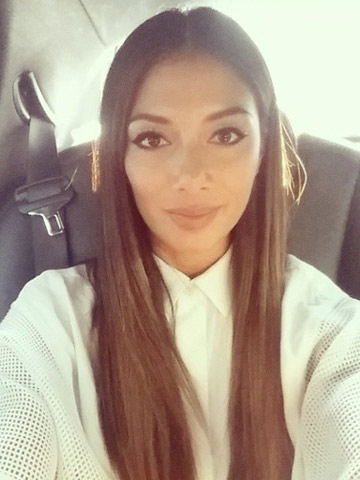

In [109]:
from PIL import Image

img1 = Image.open("/kaggle/input/hair-type-dataset/data/Straight/000028d73-Nicole_Scherzinger.jpg")
display(img1)

In [110]:
img1_transformed = train_transform(img1)
display(img1_transformed)

tensor([[[-2.1179, -2.0316, -1.6390,  ..., -1.6337, -1.2176, -0.8968],
         [-1.1877, -2.1179, -1.9431,  ..., -1.1859, -1.6005, -1.7747],
         [-1.6106, -1.2235, -1.7751,  ..., -1.0503, -1.0971, -1.1813],
         ...,
         [-1.1473, -1.1831, -1.6647,  ..., -2.1179, -2.0825, -1.7597],
         [-1.6408, -1.8520, -1.4343,  ..., -2.1179, -2.1179, -1.9065],
         [-1.5155, -1.8902, -2.0142,  ..., -1.9936, -1.8491, -2.1179]],

        [[-2.0357, -1.9475, -1.5461,  ..., -1.5407, -1.1153, -0.7874],
         [-1.0847, -2.0357, -1.8570,  ..., -1.0829, -1.5068, -1.6848],
         [-1.5171, -1.1213, -1.6853,  ..., -0.9443, -0.9921, -1.0782],
         ...,
         [-1.0434, -1.0800, -1.5724,  ..., -2.0357, -1.9996, -1.6695],
         [-1.5480, -1.7638, -1.3369,  ..., -2.0357, -2.0357, -1.8196],
         [-1.4198, -1.8029, -1.9297,  ..., -1.9087, -1.7609, -2.0357]],

        [[-1.8044, -1.7166, -1.3170,  ..., -1.3116, -0.8881, -0.5616],
         [-0.8577, -1.8044, -1.6265,  ..., -0

In [111]:
data = ImageFolder(data_root)

train_subset = int(0.8 * len(data))
val_subset = len(data) - train_subset
train_dataset, val_dataset = random_split(data, [train_subset, val_subset])

batch_size = 128  # You can adjust this number

train_dataset.dataset.transform = train_transform  # Apply the training transform
val_dataset.dataset.transform = val_transform

# Create data loaders with the specified batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [156]:
model_ft = resnet18(pretrained=True)

model_ft.fc = Linear(model_ft.fc.in_features, 5)

# Move the model to the GPU (if available)
model_ft = model_ft.to(device)

In [157]:
optimizer = Adam(model_ft.parameters(), lr=0.0001, weight_decay=1e-3)
criterion = CrossEntropyLoss()
scheduler = lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.01, total_iters=20)

In [158]:
def train(epoch):
    model_ft.train()  # Set the model to training mode
    train_loss = 0.0
    correct_preds = 0
    total_samples = 0
    
    for idx, (img, label) in enumerate(train_loader):
        img = img.to(device)  # Correct the device transfer
        label = label.to(device)

        optimizer.zero_grad()

        # Forward pass
        preds = model_ft(img)
        loss = criterion(preds, label)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Accumulate loss
        train_loss += loss.item() * img.size(0)  # Multiply by batch size for total loss
        
        # Calculate accuracy
        argmaxed_preds = preds.argmax(dim=1)  # No need for softmax before argmax
        correct_preds += (argmaxed_preds == label).sum().item()  # Get the correct predictions
        total_samples += label.size(0)

    before_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()
    after_lr = optimizer.param_groups[0]["lr"]
    print("Epoch %d: SGD lr %.4f -> %.4f" % (epoch, before_lr, after_lr))    # Calculate average loss and accuracy
    avg_loss = train_loss / total_samples
    accuracy = correct_preds / total_samples
    
    print(f"Train loss: {avg_loss:.4f}")
    print(f"Train accuracy: {accuracy * 100:.2f}%")
    print(f"Train epoch done!")
    print("*" * 50)

                
def validate():
    model_ft.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    correct_preds = 0
    total_samples = 0

    with torch.no_grad():
        for idx, (img, label) in enumerate(val_loader):  # Use val_loader, not val_dataset
            img = img.to(device)  # Correct the device transfer
            label = label.to(device)

            # Forward pass
            preds = model_ft(img)
            loss = criterion(preds, label)

            # Accumulate validation loss
            val_loss += loss.item() * img.size(0)  # Multiply by batch size for total loss

            # Calculate accuracy
            argmaxed_preds = preds.argmax(dim=1)  # No need for softmax before argmax
            correct_preds += (argmaxed_preds == label).sum().item()  # Get the correct predictions
            total_samples += label.size(0)

    # Calculate average validation loss and accuracy
    avg_loss = val_loss / total_samples
    accuracy = correct_preds / total_samples
    
    print(f"Validation loss: {avg_loss:.4f}")
    print(f"Validation accuracy: {accuracy * 100:.2f}%")
    print(f"Validation epoch done!")
    print("*" * 50)


In [159]:
epochs = 30
for epoch in range(epochs):
    train(epoch)
    validate()
    

Epoch 0: SGD lr 0.0001 -> 0.0001
Train loss: 0.8407
Train accuracy: 70.04%
Train epoch done!
**************************************************
Validation loss: 0.5156
Validation accuracy: 80.45%
Validation epoch done!
**************************************************
Epoch 1: SGD lr 0.0001 -> 0.0001
Train loss: 0.2534
Train accuracy: 91.33%
Train epoch done!
**************************************************
Validation loss: 0.4221
Validation accuracy: 86.22%
Validation epoch done!
**************************************************
Epoch 2: SGD lr 0.0001 -> 0.0001
Train loss: 0.1199
Train accuracy: 97.86%
Train epoch done!
**************************************************
Validation loss: 0.4475
Validation accuracy: 83.46%
Validation epoch done!
**************************************************
Epoch 3: SGD lr 0.0001 -> 0.0001
Train loss: 0.0589
Train accuracy: 98.99%
Train epoch done!
**************************************************
Validation loss: 0.3684
Validation accuracy: 8

In [160]:
import os

def get_images_list(root):
    imgs = []
    for filename in os.listdir(root):
        filepath = os.path.join(root, filename)
        img = Image.open(filepath)
        imgs.append(img)
    return imgs

def predict_hairstyle(img):
    pred = model_ft(img)
    index = torch.argmax(pred, dim=1).item()
    return index

In [161]:
root = "/kaggle/input/lukatest"
images = get_images_list(root)

In [162]:
correct = 0
preds = []
for image in images:
    transformed_img = val_transform(image).to(device).unsqueeze(dim=0)
    pred = predict_hairstyle(transformed_img)
    correct += (data.classes[pred] == "Straight")
    print(data.classes[pred])
    preds.append(data.classes[pred])
print(f"Model accuracy: {(correct/len(images))*100}%")

Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
kinky
Straight
Straight
Straight
dreadlocks
Straight
Straight
Straight
Straight
Straight
kinky
Straight
Straight
Straight
kinky
Straight
Straight
Straight
Model accuracy: 86.66666666666667%


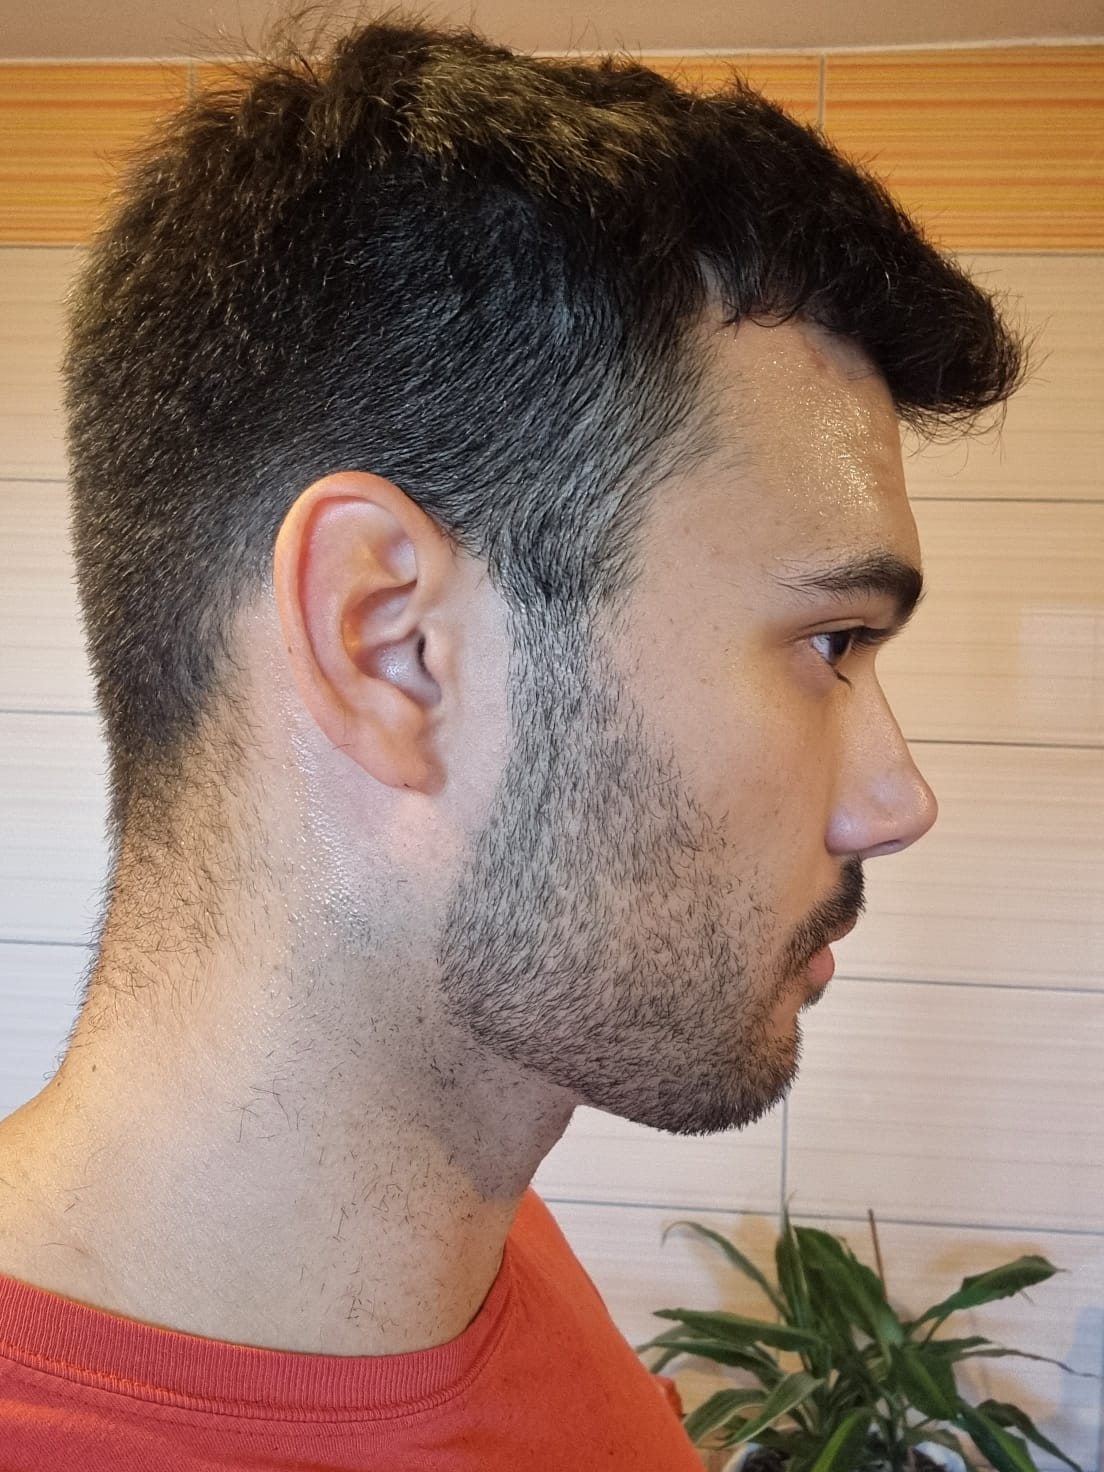

kinky
******************************


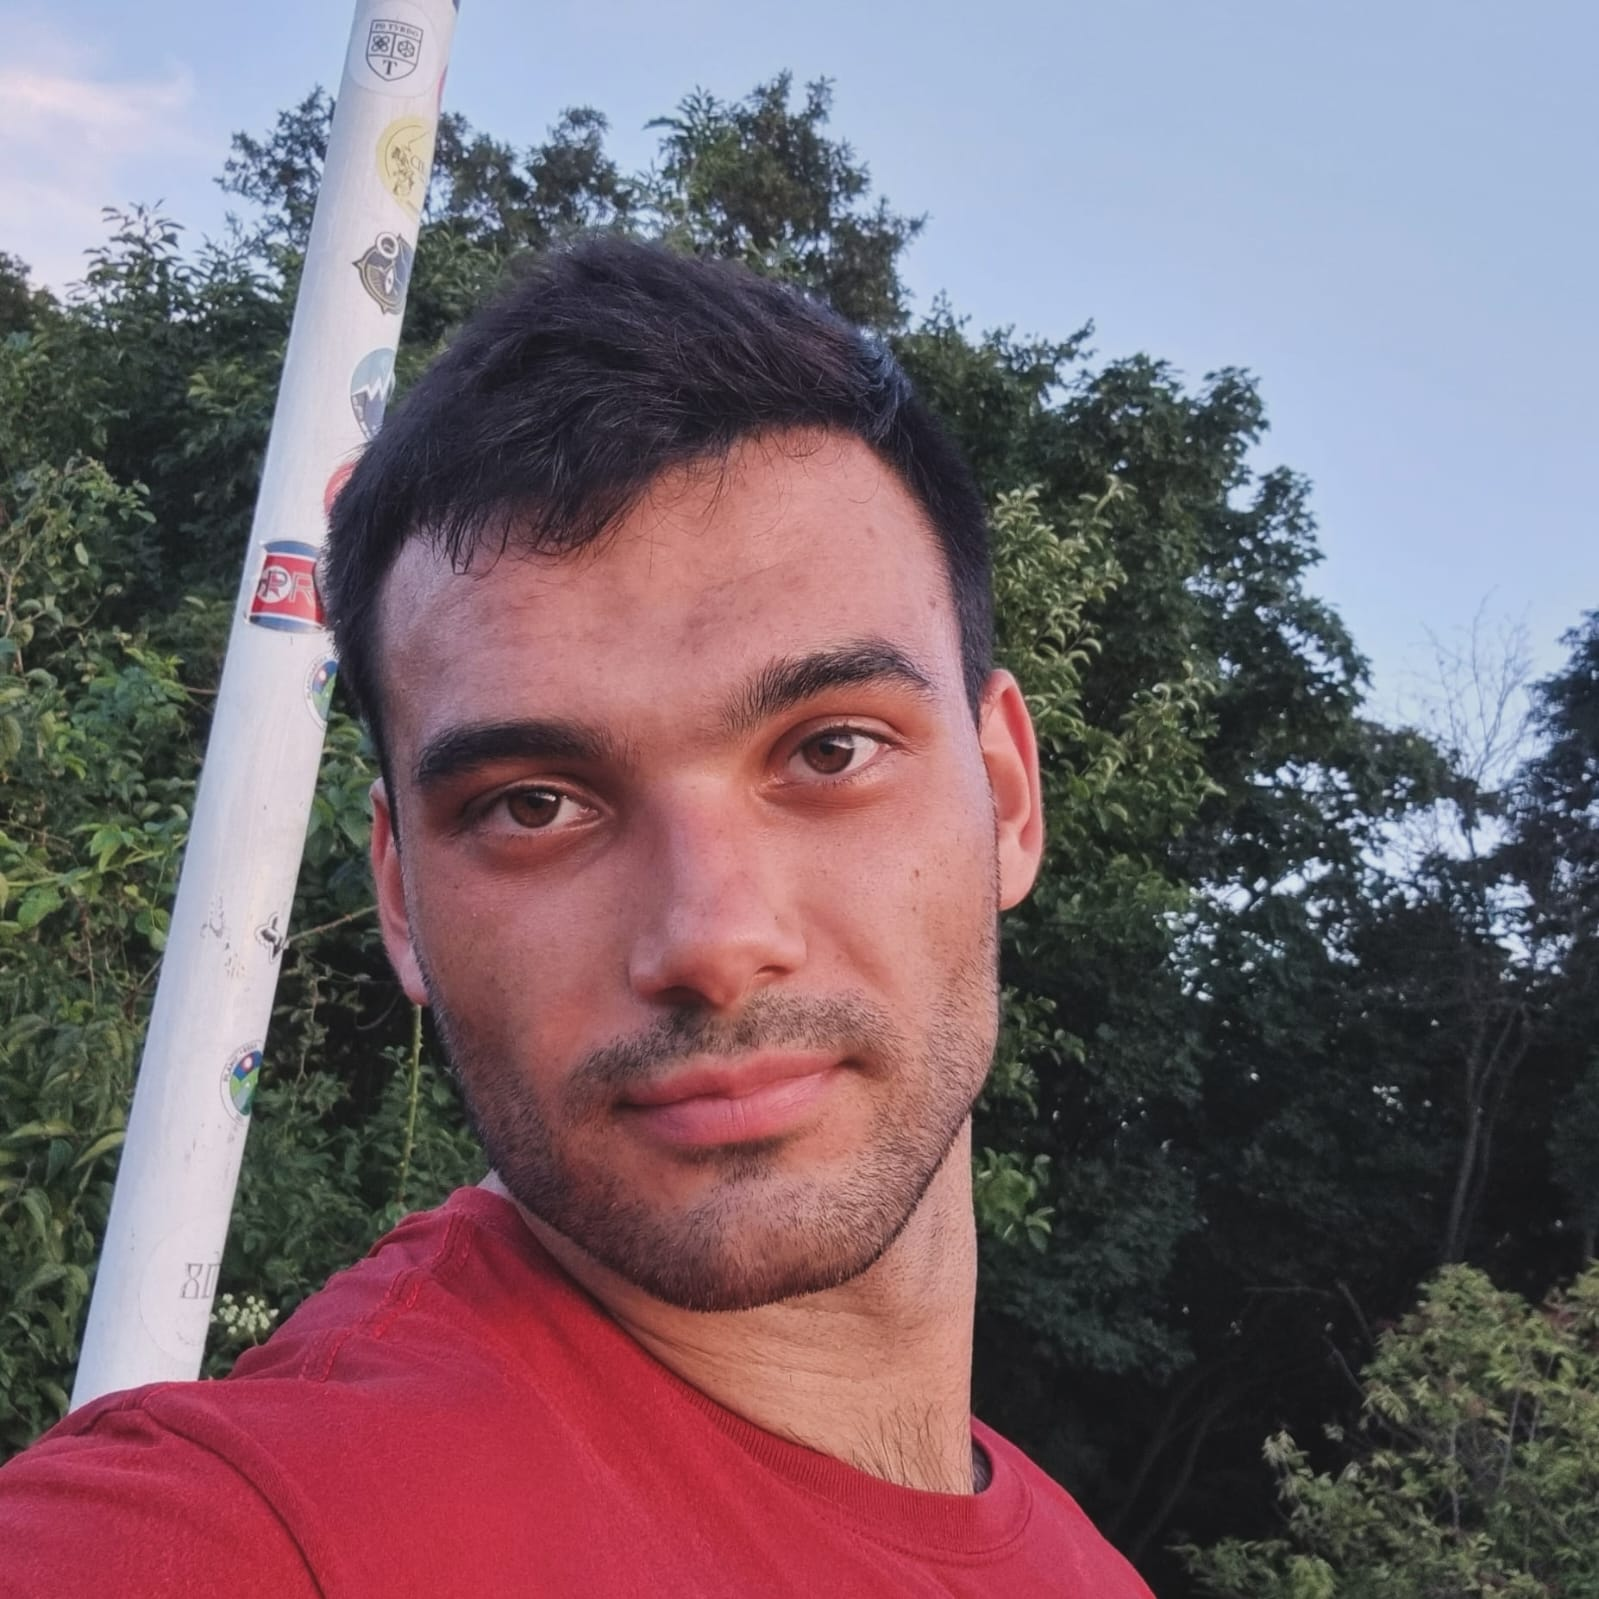

kinky
******************************


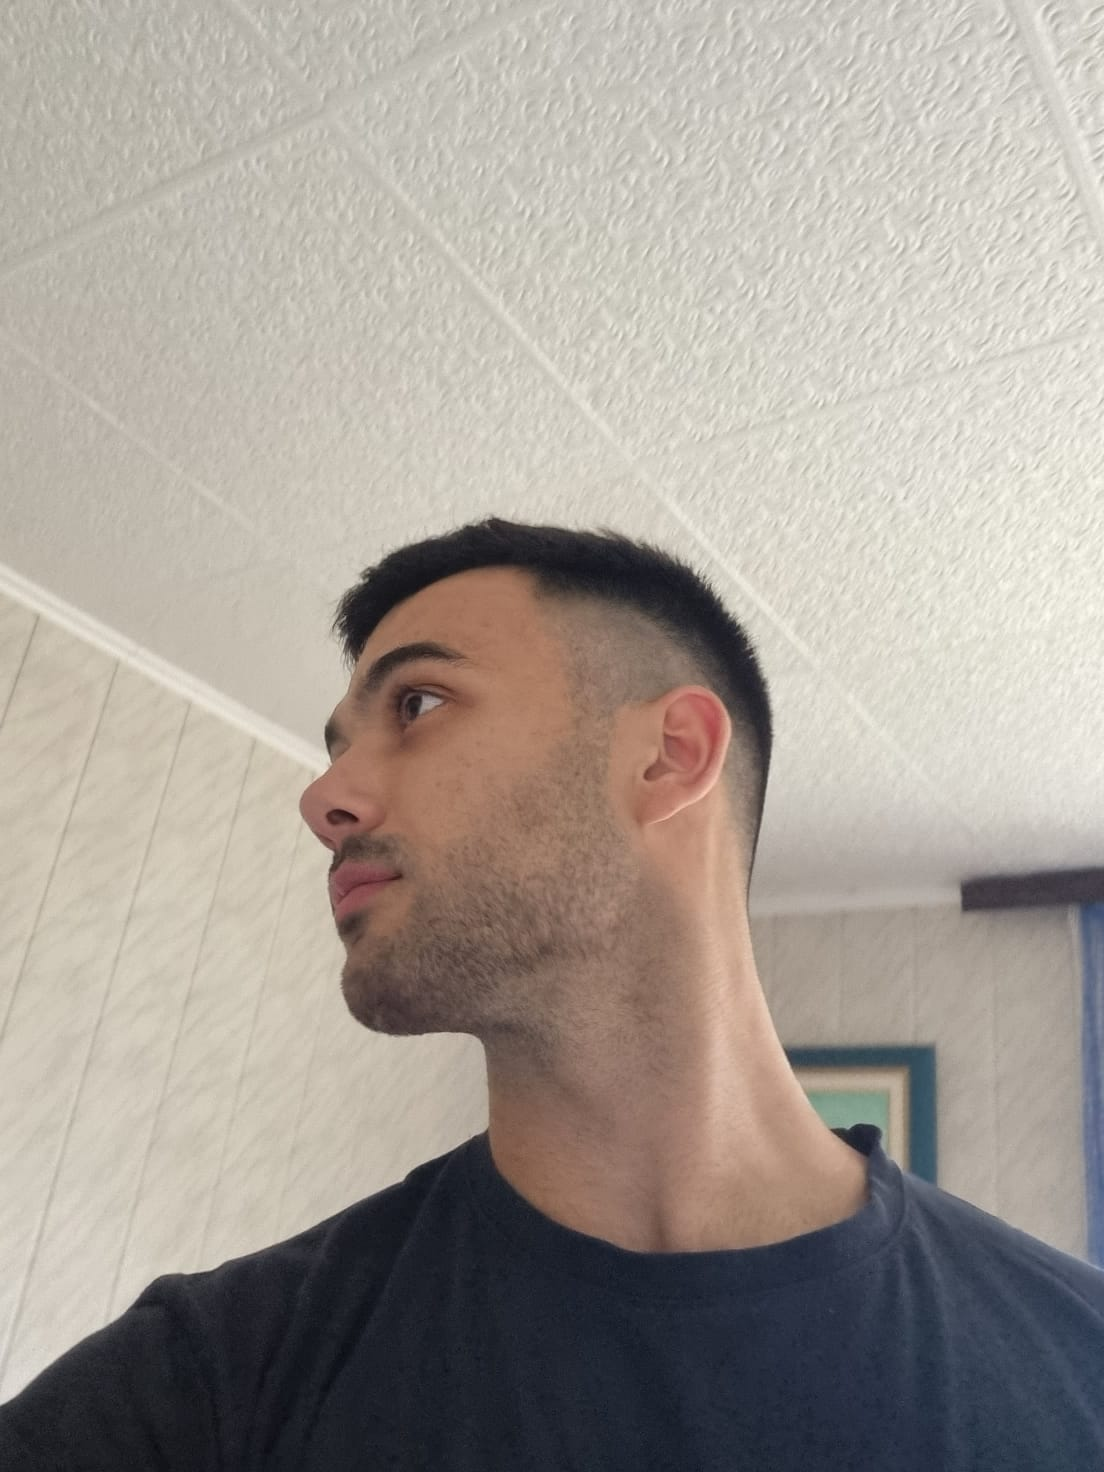

kinky
******************************


In [164]:
for pred, image in zip(preds, images):
    if pred == "kinky":
        display(image)
        print(pred)
        print("*"*30)